In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd, orth, qr
from scipy.optimize import curve_fit
from numpy import sin, cos, pi
cmap = plt.cm.plasma
from scipy.ndimage import gaussian_filter1d
from scipy.signal import wiener
from scipy.interpolate import (RegularGridInterpolator, RectBivariateSpline,
                               interpn, griddata, Rbf, interp1d, interp2d)

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
plot_width_in = page_width_pt*pt2in/2
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 1.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=12, serif='Computer Modern Roman')
pth = "../Plots/"

8.030570172000001


In [3]:
m, n = 400, 10
w = 15  # width of the bump in # nodes
x = np.linspace(0, 1, m, endpoint=False)
mu = np.linspace(0, 1, n, endpoint=False)
xi = 0.35
sigma = 19

In [4]:
def plot_paramspace(X):
    fig, ax = plt.subplots()
    plt.imshow(X, interpolation="none")
    ax.set_xlabel("$\mu$")
    ax.set_ylabel("$x$")
    ax.set_aspect(1/10)
    plt.show()
    return fig, ax

In [5]:
def bump(x, mu):
    y = np.zeros_like(x)
    i = np.argmin(np.abs(x-mu))
    y[(i-w):(i+w-1)] = 1.0
    return y

In [6]:
def predict(VT, grid, r, xi):
    method = "linear"
    V_interpolated = np.zeros((r, 1))
    for mode in range(r):
        interpolator = interp1d(grid[0], VT[mode, :], kind=method)
        V_interpolated[mode] = interpolator(xi)
    return V_interpolated

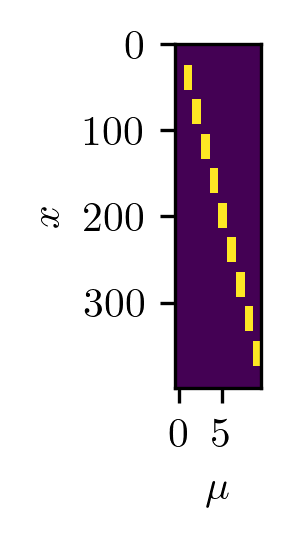

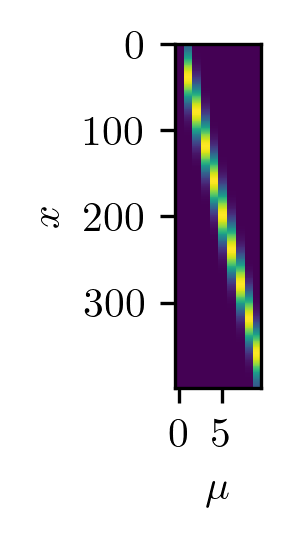

In [7]:
X = np.zeros((m, n))
X_c = np.zeros_like(X)
for j, mu_j in enumerate(mu):
    y = bump(x, mu_j)
    X[:, j] = y
    X_c[:, j] = gaussian_filter1d(y, 18.77)
plot_paramspace(X)
plt.show()
plot_paramspace(X_c)
plt.show()

In [8]:
U, S, VT = np.linalg.svd(X, False)
U_c, S_c, VT_c = np.linalg.svd(X_c, False)

In [9]:
grid = [mu,]

In [10]:
VT_intp = predict(VT, grid, min(m, n), xi)
X_intp = (U*S) @ VT_intp

VT_intp_c = predict(VT_c, grid, min(m, n), xi)
X_intp_c = (U_c*S_c) @ VT_intp_c

Text(0, 0.5, 'y')

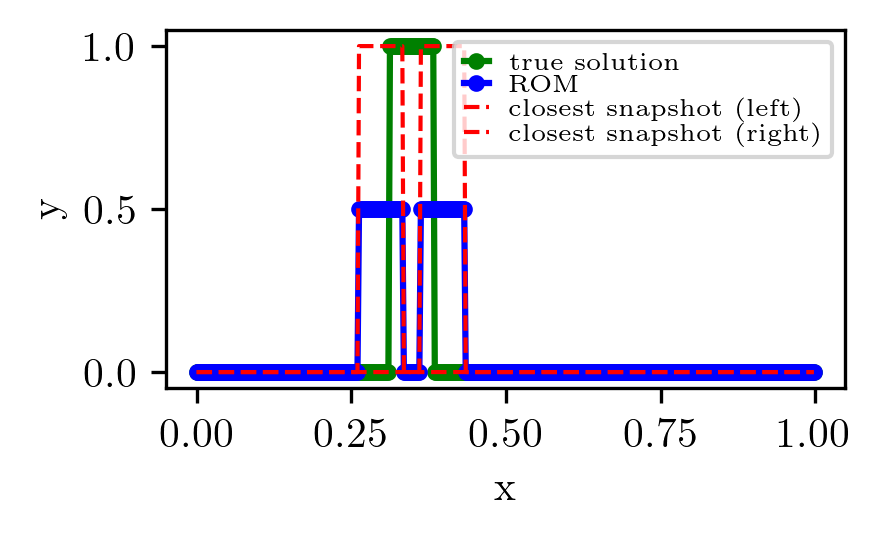

In [11]:
plt.plot(x, bump(x, 0.35), "g.-", label="true solution")
plt.plot(x, X_intp[:, 0], "b.-", label="ROM")
#plt.plot(x, X_intp_c[:, 0], "r.-", label="convolution + ROM")

plt.plot(x, X[:, 3], "r--", lw=1, label="closest snapshot (left)")
plt.plot(x, X[:, 4], "r--", lw=1, label="closest snapshot (right)")

#plt.plot(x, X_c[:, 3], "r--", lw=1, label="closest smoothened snapshot (left)")
#plt.plot(x, X_c[:, 4], "r--", lw=1, label="closest smoothened snapshot (right)")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")

In [12]:
np.sum((bump(x, 0.35)-X_intp[:, 0])**2)**.5

5.04975246918104

Text(0, 0.5, 'y')

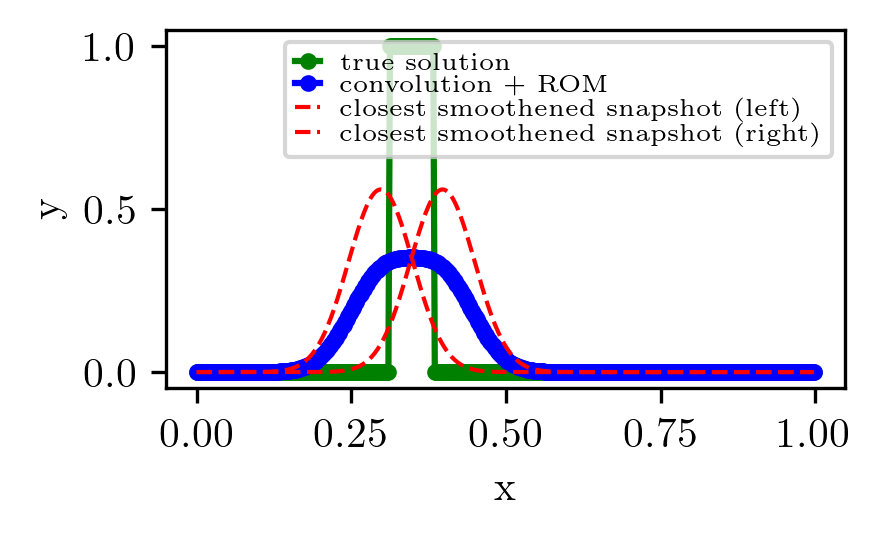

In [13]:
plt.plot(x, bump(x, 0.35), "g.-", label="true solution")
#plt.plot(x, X_intp[:, 0], "b.-", label="ROM")
plt.plot(x, X_intp_c[:, 0], "b.-", label="convolution + ROM")

#plt.plot(x, X[:, 3], "r--", lw=1, label="closest snapshot (left)")
#plt.plot(x, X[:, 4], "r--", lw=1, label="closest snapshot (right)")

plt.plot(x, X_c[:, 3], "r--", lw=1, label="closest smoothened snapshot (left)")
plt.plot(x, X_c[:, 4], "r--", lw=1, label="closest smoothened snapshot (right)")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")

In [14]:
np.sum((bump(x, 0.35)-X_intp_c[:, 0])**2)**.5

4.098666412149744

29 29


Text(0, 0.5, 'y')

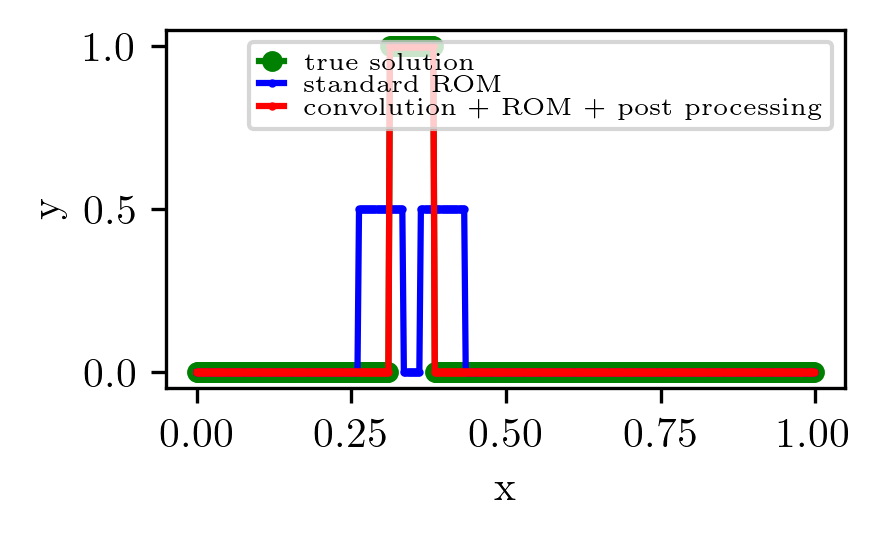

In [15]:
# physics informed post processing. Here: find largest 3 elements.
# other options: wiener deconvolution, threshold methods, ... 

ind = np.argpartition(X_intp_c[:, 0], -29)[-29:]
X_intp_c_post = np.zeros_like(X_intp_c)
X_intp_c_post[ind, 0] = 1
print(np.sum(bump(x, 0.35)>.5), np.sum(X_intp_c_post[:, 0]>.5))

plt.plot(x, bump(x, 0.35), "g.-", ms=8, label="true solution")
plt.plot(x, X_intp[:, 0], "b.-", ms=2, label="standard ROM")
plt.plot(x, X_intp_c_post[:, 0], "r.-", ms=2, label="convolution + ROM + post processing")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")

29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 29
29 2

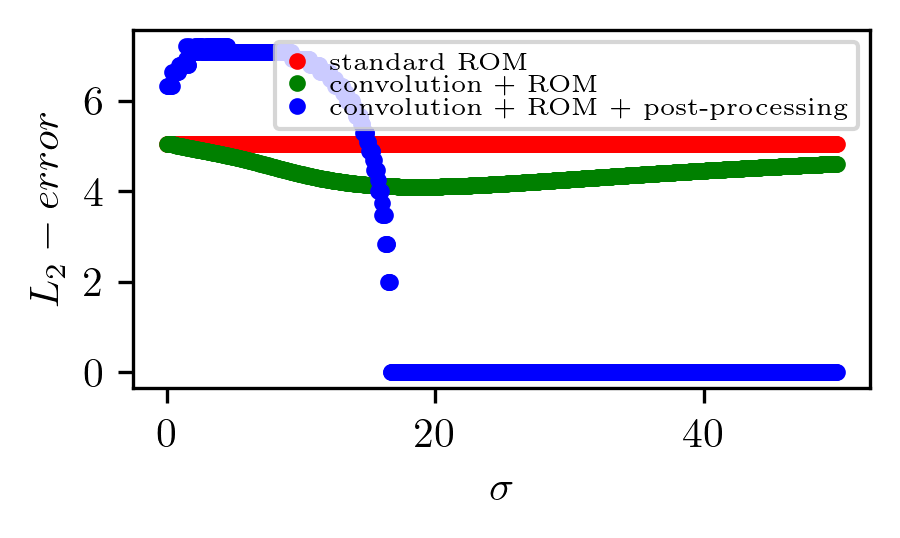

In [17]:
sigmas = np.linspace(1e-6, 50, 1000)
sigmas[-1] = 18.768
e1 = np.zeros_like(sigmas)
e2 = np.zeros_like(sigmas)
e3 = np.zeros_like(sigmas)
for i, sigma in enumerate(sigmas):
    for j, mu_j in enumerate(mu):
        X_c[:, j] = gaussian_filter1d(X[:, j], sigma)
    U_c, S_c, VT_c = np.linalg.svd(X_c, False)

    VT_intp_c = predict(VT_c, grid, min(m, n), xi)
    X_intp_c = (U_c*S_c) @ VT_intp_c

    ind = np.argpartition(X_intp_c[:, 0], -29)[-29:]
    X_intp_c_post = np.zeros_like(X_intp_c)
    X_intp_c_post[ind, 0] = 1
    print(np.sum(bump(x, 0.35) > .5), np.sum(X_intp_c_post[:, 0] > .5))

    e1[i] = np.sum((bump(x, 0.35)-X_intp[:, 0])**2)**.5
    e2[i] = np.sum((bump(x, 0.35)-X_intp_c[:, 0])**2)**.5
    e3[i] = np.sum((bump(x, 0.35)-X_intp_c_post[:, 0])**2)**.5
# ---------------------------

fig, ax = plt.subplots()
ax.plot(sigmas, e1, "r.", label="standard ROM")
ax.plot(sigmas, e2, "g.", label="convolution + ROM")
ax.plot(sigmas, e3, "b.", label="convolution + ROM + post-processing")
plt.xlabel("$\sigma$")
plt.ylabel("$L_2- error$")
plt.legend()
plt.show()